# EEG Oddball Visualization

**Mục tiêu:** Tạo các biểu đồ rõ ràng, có ý nghĩa để đưa vào báo cáo.

**Công việc chính:**
- ⭐️ Biểu đồ ERP (Event-Related Potential) tại kênh Pz - so sánh Target vs Standard
- Biểu đồ thanh so sánh accuracy giữa các subjects
- **Nâng cao:** So sánh Band Power vs HMM Features

**Dữ liệu:**
- `processed_data.pkl`: MNE Epochs (raw time-series)
- `data/eeg.csv`: Band Power features
- `data/hmm.csv`: HMM features
- `results/model_performance_summary.csv`: Model results

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 100, 'savefig.dpi': 300})

BLUE, ORANGE, GREEN, PURPLE = '#4472C4', '#ED7D31', '#70AD47', '#9B59B6'

# Load data
eeg_df = pd.read_csv('../data/eeg.csv')
hmm_df = pd.read_csv('../data/hmm.csv')
results_df = pd.read_csv('../results/model_performance_summary.csv')

# Load epochs
from mne import concatenate_epochs
with open('../processed/processed_data.pkl', 'rb') as f:
    epochs = concatenate_epochs(list(pickle.load(f).values()))

print(f"✓ Data loaded: {len(eeg_df)} rows | {len(epochs)} epochs")

Not setting metadata
1005 matching events found
Applying baseline correction (mode: mean)
✓ Data loaded: 847 rows | 1005 epochs


In [34]:
# Helper functions
def get_channel_idx(epochs, ch='Pz'):
    for c in [ch, ch.upper(), 'Cz']:
        if c in epochs.ch_names:
            return epochs.ch_names.index(c), c
    return 0, epochs.ch_names[0]

def get_event_epochs(epochs, event):
    mapping = {'target': 'Stimulus/S  6', 'standard': 'Stimulus/S  5'}
    return epochs[mapping[event]]

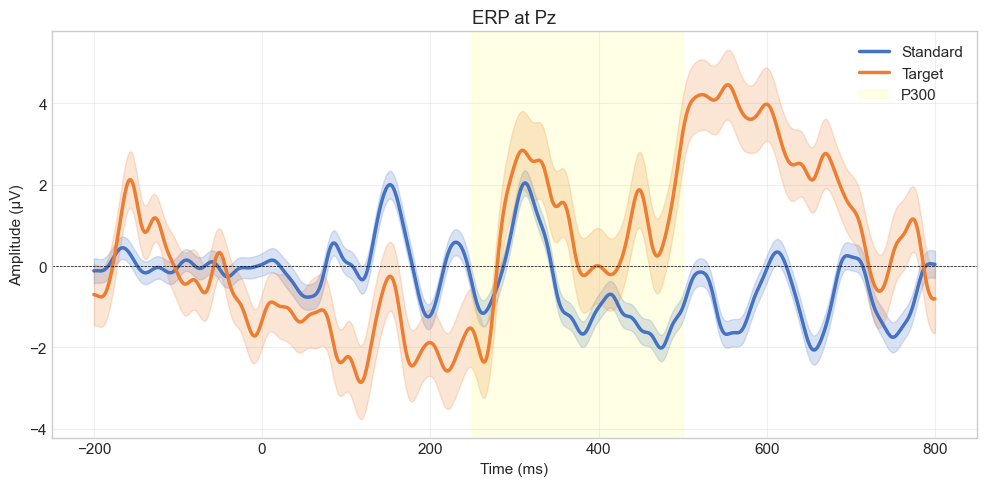

In [35]:
# 1. ERP Plot
if epochs is None:
    print("⚠️ No epochs data")
else:
    pz_idx, ch = get_channel_idx(epochs)
    times = epochs.times * 1000
    
    fig, ax = plt.subplots(figsize=(10, 5))
    for event, label, color in [('standard', 'Standard', BLUE), ('target', 'Target', ORANGE)]:
        data = get_event_epochs(epochs, event).get_data()[:, pz_idx, :] * 1e6
        mean, sem = data.mean(0), stats.sem(data, 0)
        ax.plot(times, mean, label=label, color=color, lw=2.5)
        ax.fill_between(times, mean-sem, mean+sem, alpha=0.2, color=color)
    
    ax.axhline(0, color='k', ls='--', lw=0.5)
    ax.axvspan(250, 500, alpha=0.1, color='yellow', label='P300')
    ax.set(xlabel='Time (ms)', ylabel='Amplitude (μV)', title=f'ERP at {ch}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

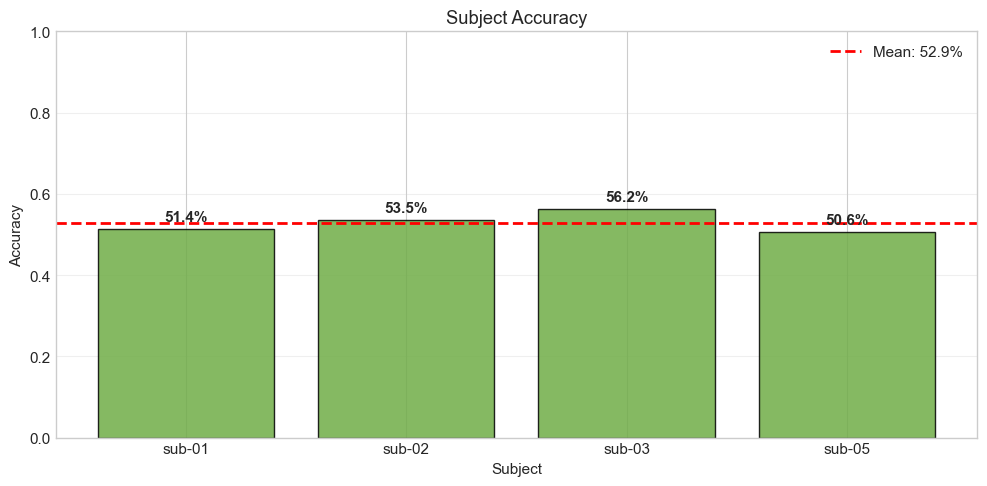

In [36]:
# 2. Subject Accuracy
subjects = sorted(eeg_df['subject_id'].unique())
accs = [(eeg_df[eeg_df['subject_id']==s]['Peak_Amp'] > 
         eeg_df[eeg_df['subject_id']==s]['Peak_Amp'].median()).astype(int).eq(
         eeg_df[eeg_df['subject_id']==s]['label']).mean() for s in subjects]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(subjects, accs, color=GREEN, edgecolor='k', alpha=0.85)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f'{acc:.1%}', ha='center', fontweight='bold')

ax.axhline(np.mean(accs), color='r', ls='--', lw=2, label=f'Mean: {np.mean(accs):.1%}')
ax.set(xlabel='Subject', ylabel='Accuracy', ylim=[0, 1], title='Subject Accuracy')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

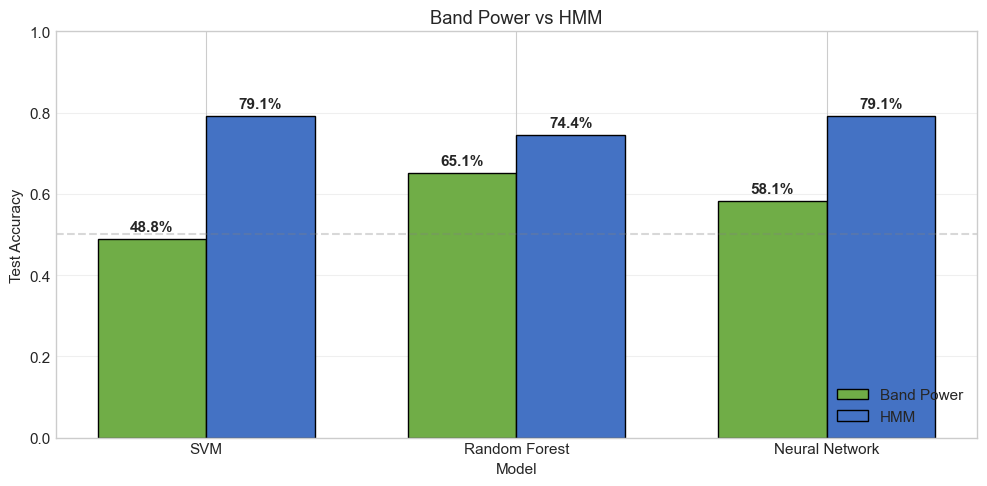

In [37]:
# 3. Band Power vs HMM
eeg_res = results_df[results_df['Feature'] == 'EEG']
hmm_res = results_df[results_df['Feature'] == 'HMM']
x, w = np.arange(len(eeg_res)), 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, eeg_res['Test_Accuracy'], w, label='Band Power', color=GREEN, edgecolor='k')
b2 = ax.bar(x + w/2, hmm_res['Test_Accuracy'], w, label='HMM', color=BLUE, edgecolor='k')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{bar.get_height():.1%}', ha='center', fontweight='bold')

ax.axhline(0.5, color='gray', ls='--', alpha=0.3)
ax.set(xlabel='Model', ylabel='Test Accuracy', ylim=[0, 1], title='Band Power vs HMM')
ax.set_xticks(x)
ax.set_xticklabels(eeg_res['Model'])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

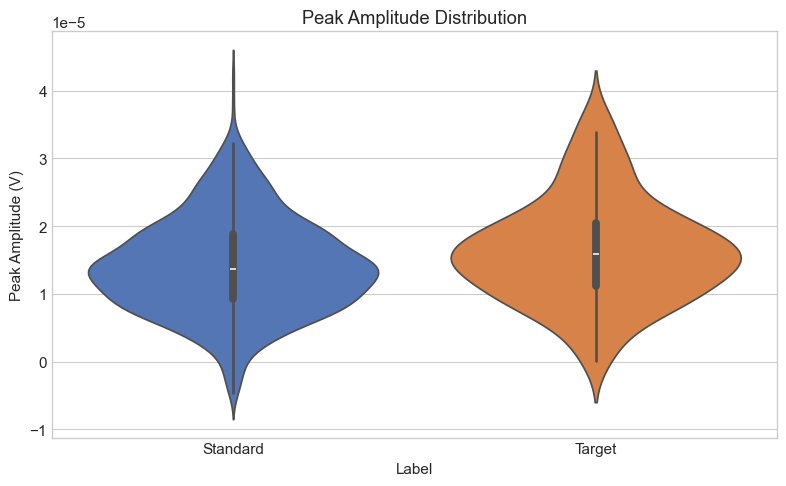

In [45]:
# 4. Peak Amplitude Distribution
eeg_df['Label'] = eeg_df['label'].map({0: 'Standard', 1: 'Target'})

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=eeg_df, x='Label', y='Peak_Amp', palette=[BLUE, ORANGE], ax=ax)
ax.set(title='Peak Amplitude Distribution', ylabel='Peak Amplitude (V)')
plt.tight_layout()
plt.show()

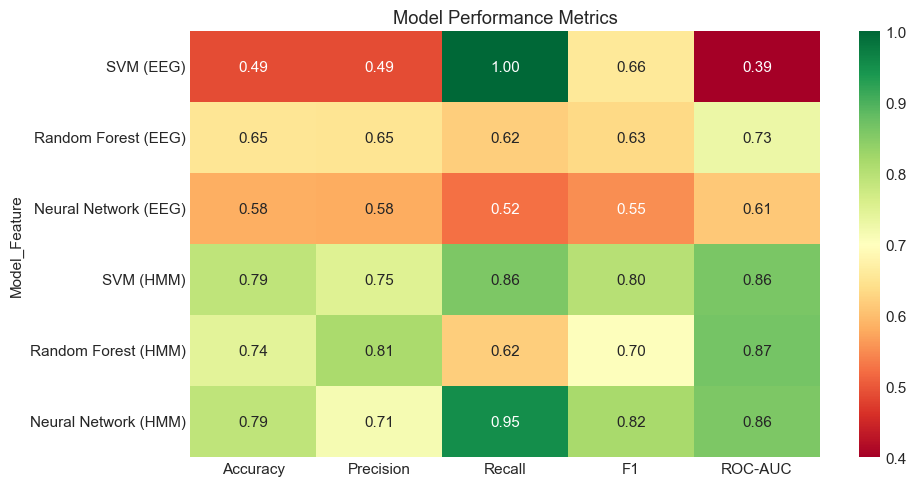

In [46]:
# 5. Performance Heatmap
metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']
results_df['Model_Feature'] = results_df['Model'] + ' (' + results_df['Feature'] + ')'
heatmap_data = results_df.set_index('Model_Feature')[metrics]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.4, vmax=1, ax=ax)
ax.set_title('Model Performance Metrics')
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
plt.tight_layout()
plt.show()

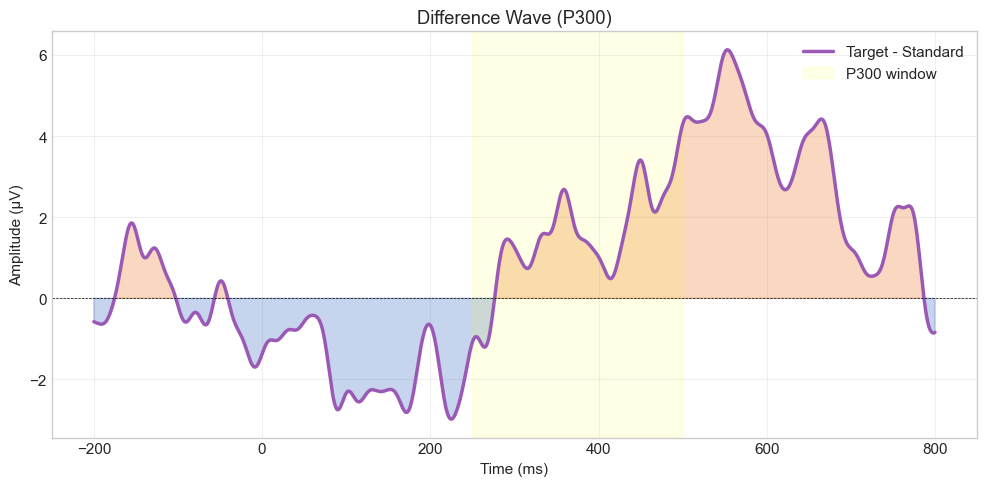

In [47]:
# 6. Difference Wave (Target - Standard)
pz_idx, ch = get_channel_idx(epochs)
times = epochs.times * 1000

target_data = get_event_epochs(epochs, 'target').get_data()[:, pz_idx, :] * 1e6
standard_data = get_event_epochs(epochs, 'standard').get_data()[:, pz_idx, :] * 1e6
diff_wave = target_data.mean(0) - standard_data.mean(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(times, diff_wave, color=PURPLE, lw=2.5, label='Target - Standard')
ax.fill_between(times, 0, diff_wave, where=(diff_wave > 0), alpha=0.3, color=ORANGE)
ax.fill_between(times, 0, diff_wave, where=(diff_wave < 0), alpha=0.3, color=BLUE)
ax.axhline(0, color='k', ls='--', lw=0.5)
ax.axvspan(250, 500, alpha=0.1, color='yellow', label='P300 window')
ax.set(xlabel='Time (ms)', ylabel='Amplitude (μV)', title='Difference Wave (P300)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

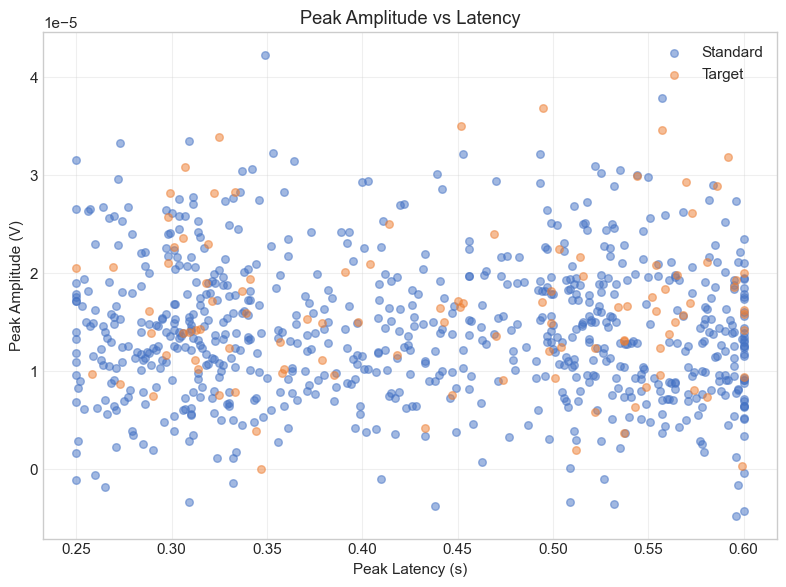

In [48]:
# 7. Peak Amplitude vs Latency
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in [(0, BLUE, 'Standard'), (1, ORANGE, 'Target')]:
    subset = eeg_df[eeg_df['label'] == label]
    ax.scatter(subset['Peak_Latency'], subset['Peak_Amp'], 
               c=color, alpha=0.5, label=name, s=30)
ax.set(xlabel='Peak Latency (s)', ylabel='Peak Amplitude (V)', 
       title='Peak Amplitude vs Latency')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

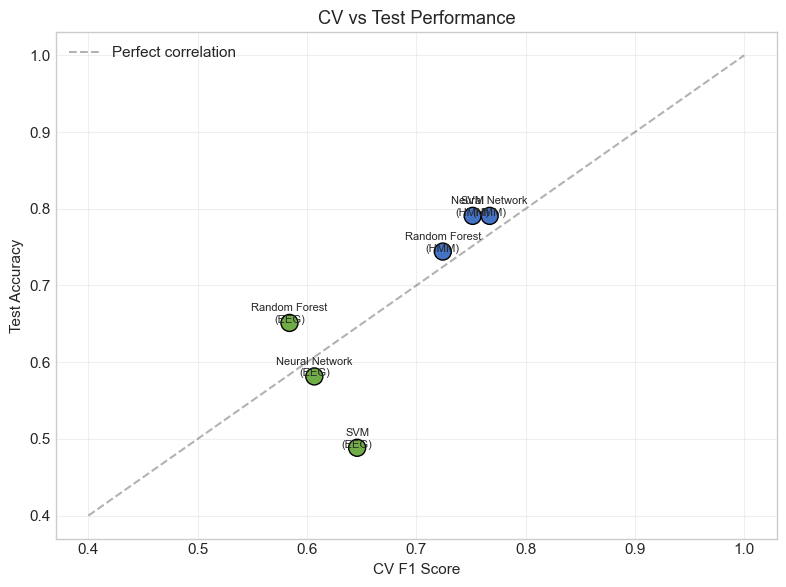

In [49]:
# 8. CV F1 vs Test Accuracy
fig, ax = plt.subplots(figsize=(8, 6))
colors = [GREEN if f=='EEG' else BLUE for f in results_df['Feature']]
ax.scatter(results_df['CV_F1'], results_df['Test_Accuracy'], c=colors, s=150, edgecolor='k')

for i, row in results_df.iterrows():
    ax.annotate(f"{row['Model']}\n({row['Feature']})", 
                (row['CV_F1'], row['Test_Accuracy']), fontsize=8, ha='center')

ax.plot([0.4, 1], [0.4, 1], 'k--', alpha=0.3, label='Perfect correlation')
ax.set(xlabel='CV F1 Score', ylabel='Test Accuracy', title='CV vs Test Performance')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

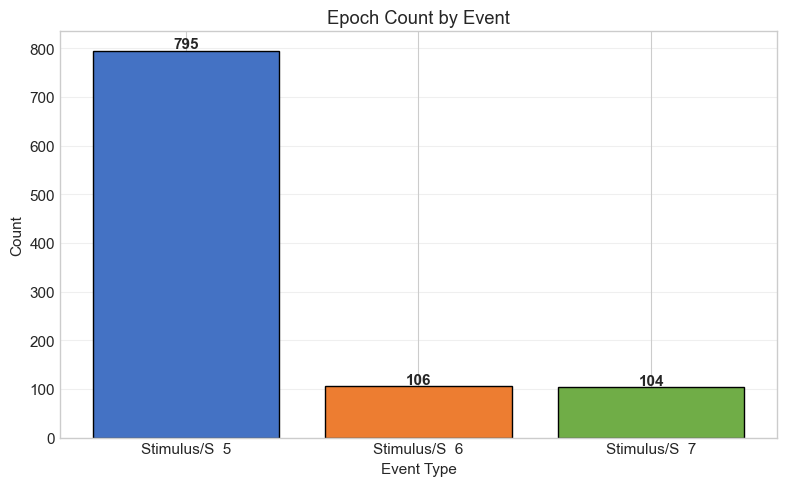

In [50]:
# 9. Epoch Count by Event Type
event_counts = {name: len(epochs[name]) for name in epochs.event_id.keys()}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(event_counts.keys(), event_counts.values(), color=[BLUE, ORANGE, GREEN], edgecolor='k')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(int(bar.get_height())), ha='center', fontweight='bold')
ax.set(xlabel='Event Type', ylabel='Count', title='Epoch Count by Event')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()